In [2]:
import pickle

from matplotlib import pyplot as plt, cm
import numpy as np
import json
import os
import matplotlib.colors as mcolors

def getfolder(target_path, timepoint):
    file_path = os.path.join(target_path, timepoint)

    folders = [f for f in os.listdir(file_path) if os.path.isdir(os.path.join(file_path, f))]

    checkpoint_folders = []
    for folder in folders:
        if folder.startswith('checkpoint-'):
            try:
                num = int(folder.split('-')[1])
                checkpoint_folders.append((num, folder))
            except ValueError:
                continue 

    # 找到数字最大的一项
    if checkpoint_folders:
        max_num, max_folder = max(checkpoint_folders, key=lambda x: x[0])
        return os.path.join(target_path, timepoint,max_folder)
    else:
        print("No checkpoints found.")
def getValues(target_path,type = 'spatial'):
    timepoints = ['0h','12h','1.5d','3d','5d','10d','WT']
    history_best = {}
    if type == 'spatial':
        for timepoint in timepoints:
            history_best[timepoint] = []
            history_item = []
            file_path = target_path+timepoint+'/history.txt'
            with open(file_path,'r') as file:
                lines = file.readlines()
            for line in lines:
                line = line.strip('\n')
                line = line.split(' ')
                history_item.append([float(line[0]),float(line[1])])
            sorted_history_item = sorted(history_item, key=lambda x: x[0],reverse=True)
            history_best[timepoint] = sorted_history_item[0]
        
    if type == 'gene':
        for timepoint in timepoints:
            history_best[timepoint] = []
            history_item = []
            file_path = getfolder(target_path,timepoint) +'/trainer_state.json'
            with open(file_path, 'r') as file:
                data = json.load(file)
            history_item = []
            for item in data['log_history']:
                if 'eval_accuracy' in item and 'eval_macro_f1' in item:
                    history_item.append([
                      item['eval_accuracy'],
                         item['eval_macro_f1']
                    ])
            sorted_history_item = sorted(history_item, key=lambda x: x[0], reverse=True)
            history_best[timepoint] = sorted_history_item[0]
    return history_best
# getValues(target_path ='./model_compare_celltype/gene_raw/',type = 'gene')
# getValues(target_path ='./model_compare_celltype/gene_aug/',type = 'gene')
# getValues(target_path ='./model_compare_celltype/spatial_raw/')
# getValues(target_path ='./model_compare_celltype/spatial_aug/')
def makeComparePlot():
    geneformer_raw_history = getValues(target_path ='../result/model_results/geneformer/',type = 'gene')
    geneformer_with_pretrained_history = getValues(target_path ='../result/model_results/gene_raw/',type = 'gene')
    geneformer_with_pretrained_history_Spatial =getValues(target_path ='../result/model_results/spatial_raw/')
    geneformer_with_pretrained_history_Spatial_Time = getValues(target_path='../result/model_results/time_spatial_raw/')
    timepoints = ['0h', '12h', '1.5d', '3d', '5d', '10d', 'WT']
    
    
    score_matrix_acc = [
        [geneformer_raw_history[timepoint][0] for timepoint in timepoints],  
        [geneformer_with_pretrained_history[timepoint][0] for timepoint in timepoints],  
        [geneformer_with_pretrained_history_Spatial[timepoint][0] for timepoint in timepoints], 
        [geneformer_with_pretrained_history_Spatial_Time[timepoint][0] for timepoint in timepoints], 
    ]
    
    score_matrix_acc = np.array(score_matrix_acc)
    print(score_matrix_acc)
    score_matrix_f1 = [
        [geneformer_raw_history[timepoint][1] for timepoint in timepoints],  
        [geneformer_with_pretrained_history[timepoint][1] for timepoint in timepoints], 
        [geneformer_with_pretrained_history_Spatial[timepoint][1] for timepoint in timepoints],  
        [geneformer_with_pretrained_history_Spatial_Time[timepoint][1] for timepoint in timepoints], 
    ]
    
    # 转换为numpy数组
    score_matrix_f1 = np.array(score_matrix_f1)

    
    timepoints = ['0h', '12h', '36h', '72h', '120h', '240h', 'WT']
    models = ['Geneformer with planarian and ST','Geneformer with planarian and Spatial','Geneformer with planarian' ,'Geneformer']
    models = ['Geneformer','PFM','PFM with Spatial','PFM with ST']
    base_colors = ['red', 'orange', 'blue', 'yellow', 'green', 'purple', 'black']
    score_matrix =  score_matrix_acc
    # 确定评分的最小值和最大值
    vmin = np.min(score_matrix)
    vmax = np.max(score_matrix)
    # vmax =0.75
    # 创建绘图
    fig, ax = plt.subplots(figsize=(8, 4))
    
    for i, model in enumerate(models):
        for j, timepoint in enumerate(timepoints):
            base_color = mcolors.to_rgba(base_colors[j], alpha=1.0) 
            
            intensity = (score_matrix[i, j] - vmin) / (vmax - vmin)  
            color = tuple([(1-intensity) * (1 - c) + c for c in base_color[:3]])  
            
            ax.scatter(j, i*1, color=color, s=2000, edgecolor='black', marker='o', zorder=10)
          
    
    ax.set_xticks(np.arange(len(timepoints)))
    ax.set_xticklabels(timepoints, rotation=45)
    ax.set_yticks(np.linspace(0, len(models) - 1, len(models)) * 1)  
    ax.set_yticklabels(models, rotation=0)
    ax.set_ylim(-0.9, len(models))  
    ax.set_xlim(-0.9, len(timepoints)) 

    cbar = fig.colorbar(plt.cm.ScalarMappable(cmap='Greys', norm=plt.Normalize(vmin=vmin, vmax=vmax)), ax=ax)
    
    # 添加标题
    ax.set_title('Model Acc-Score Performance Over Time')
    
    # 调整布局
    plt.tight_layout(pad = 20.0)
    
    plt.savefig("../result/model_performance_acc.pdf", dpi=300, bbox_inches='tight', format='pdf')
    plt.savefig("../result/model_performance_acc.svg", bbox_inches='tight', format='svg')
    score_matrix =  score_matrix_f1
    # 确定评分的最小值和最大值
    vmin = np.min(score_matrix)
    vmax = np.max(score_matrix)
    # vmax =0.75
    # 创建绘图
    fig, ax = plt.subplots(figsize=(8, 4))
    
    # 为每个时间点绘制不同颜色基调的圆点
    for i, model in enumerate(models):
        for j, timepoint in enumerate(timepoints):
            base_color = mcolors.to_rgba(base_colors[j], alpha=1.0)  
            
            intensity = (score_matrix[i, j] - vmin) / (vmax - vmin)  
            color = tuple([(1-intensity) * (1 - c) + c for c in base_color[:3]])  
            
            ax.scatter(j, i*1, color=color, s=2000, edgecolor='black', marker='o', zorder=10)
          
    
    ax.set_xticks(np.arange(len(timepoints)))
    ax.set_xticklabels(timepoints, rotation=45)
    ax.set_yticks(np.linspace(0, len(models) - 1, len(models)) * 1)  
    ax.set_yticklabels(models, rotation=0)
    ax.set_ylim(-0.9, len(models))  
    ax.set_xlim(-0.9, len(timepoints))  
    cbar = fig.colorbar(plt.cm.ScalarMappable(cmap='Greys', norm=plt.Normalize(vmin=vmin, vmax=vmax)), ax=ax)
    
    # 添加标题
    ax.set_title('Model F1-Score Performance Over Time')
    
    # 调整布局
    plt.tight_layout(pad = 20.0)
    
    plt.savefig("../result/model_performance_f1.pdf", dpi=300, bbox_inches='tight', format='pdf')
    plt.savefig("../result/model_performance_f1.svg", bbox_inches='tight', format='svg')
    
    
    # plt.savefig('Acc.png',dpi = 3000)

[[0.59400084 0.50604651 0.60534759 0.58972618 0.58438605 0.60910031
  0.63823154]
 [0.6539924  0.63069767 0.65695187 0.66259335 0.67635169 0.66907963
  0.70724104]
 [0.66894043 0.64987013 0.68762978 0.67351541 0.68898488 0.71001553
  0.72370665]
 [0.70259209 0.68987013 0.71699792 0.69080431 0.71181734 0.73059006
  0.73635588]]


/tmp/ipykernel_1290914/2523358138.py:149: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(pad = 20.0)
/tmp/ipykernel_1290914/2523358138.py:191: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(pad = 20.0)


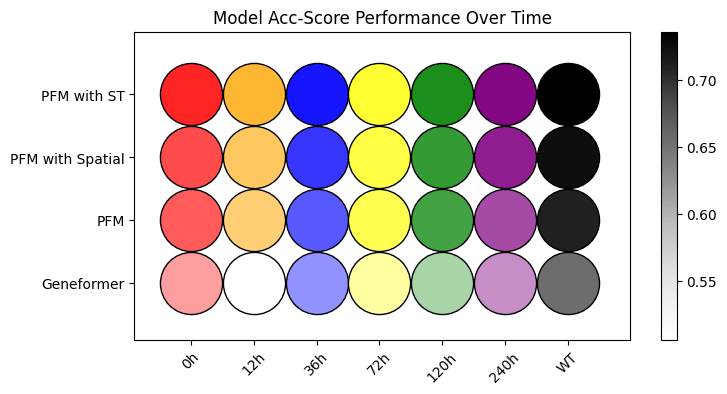

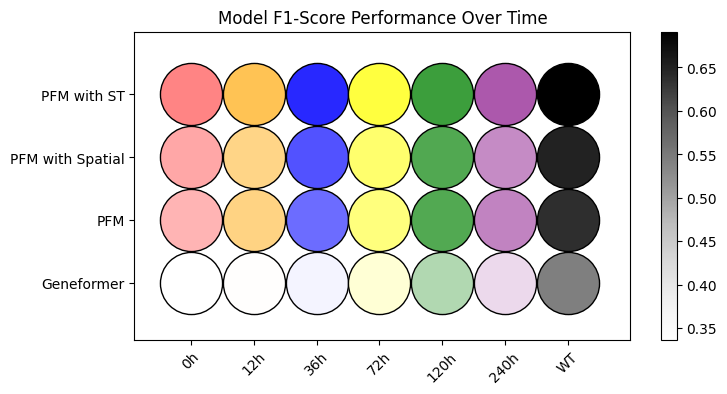

In [3]:
makeComparePlot()

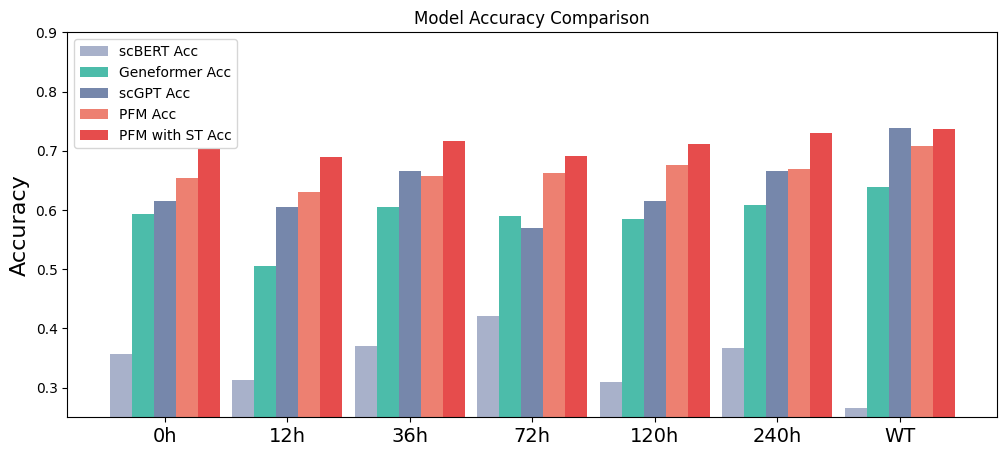

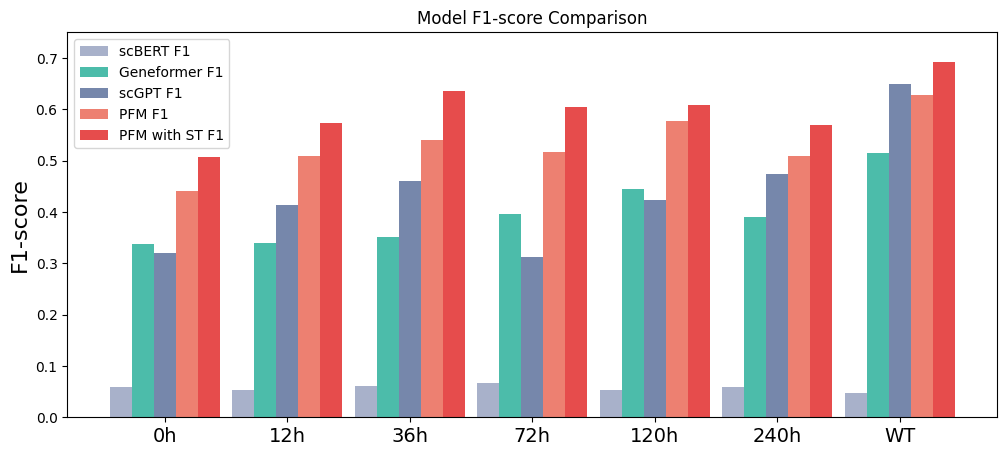

In [5]:
import pickle
def makeComparePlot2():
    timepoints = ['0h', '12h', '1.5d', '3d', '5d', '10d', 'WT']
    timepoints_name = ['0h', '12h', '36h', '72h', '120h', '240h', 'WT']
    history_scgpt_acc = []
    history_scgpt_f1 = []
    for timepoint in timepoints:
        with open('../scGPT/scGPT-main/save/dev_'+timepoint+'/model_history.pkl', 'rb') as f:
            history_timepoint = pickle.load(f)
            #print(history_timepoint)
            sorted_history_item = sorted(history_timepoint, key=lambda x: x['test/accuracy'], reverse=True)
            sorted_history_item = sorted_history_item[0]
            history_scgpt_acc.append(sorted_history_item['test/accuracy'])
            history_scgpt_f1.append(sorted_history_item['test/macro_f1'])
    history_scBERT = {}
    for timepoint in timepoints:
        with open('../scBERT/scBERT-master/ckpts/'+timepoint+'/history.txt', 'r') as f:
            lines = f.readlines()
            history_item = []
            for line in lines:
                line = line.strip('\n')
                line = line.split(' ')
                history_item.append([float(line[0]),float(line[1])])
            sorted_history_item = sorted(history_item, key=lambda x: x[0],reverse=True)
            history_scBERT[timepoint] = sorted_history_item[0]
        # history_scBERT['WT'] = [0.33,0.05]
    gene_raw_history = getValues(target_path ='../result/model_results/gene_raw/',type = 'gene')
    geneformer_history = getValues(target_path ='../result/model_results/geneformer/',type = 'gene')
    spatial_time_history = getValues(target_path ='../result/model_results/time_spatial_raw/',type = 'spatial')
    geneformer_acc = [geneformer_history[timepoint][0] for timepoint in timepoints]
    geneformer_pretrained_acc = [gene_raw_history[timepoint][0] for timepoint in timepoints]
    scBERT_acc = [history_scBERT[timepoint][0] for timepoint in timepoints]
    geneformer_ST_acc = [ spatial_time_history[timepoint][0] for timepoint in timepoints]
    geneformer_f1 = [geneformer_history[timepoint][1] for timepoint in timepoints]
    geneformer_pretrained_f1 = [gene_raw_history[timepoint][1] for timepoint in timepoints]
    scBERT_f1 = [history_scBERT[timepoint][1] for timepoint in timepoints]
    geneformer_ST_f1 = [spatial_time_history[timepoint][1] for timepoint in timepoints]
    scgpt_acc = history_scgpt_acc
    scgpt_f1 = history_scgpt_f1
    
    # 设置条形宽度
    bar_width = 0.18
    x = np.arange(len(timepoints))
    colors = ["#8491B4FF", "#00A087FF", "#3C5488FF", "#E64B35FF" , "#DC0000FF" ]
    plt.figure(figsize=(12, 5))
    plt.bar(x - bar_width*2,scBERT_acc, width=bar_width, label="scBERT Acc", color=colors[0], alpha=0.7)
    plt.bar(x - bar_width, geneformer_acc, width=bar_width, label="Geneformer Acc", color=colors[1], alpha=0.7)
    plt.bar(x , scgpt_acc, width=bar_width, label="scGPT Acc", color=colors[2], alpha=0.7)
    plt.bar(x+bar_width, geneformer_pretrained_acc, width=bar_width, label="PFM Acc", color=colors[3], alpha=0.7)
    plt.bar(x+bar_width*2, geneformer_ST_acc, width=bar_width, label="PFM with ST Acc", color=colors[4], alpha=0.7)
 
    plt.ylim(0.25, 0.9) 
    plt.xticks(x, timepoints_name, fontsize=14)
    plt.ylabel("Accuracy", fontsize=16)
    plt.title("Model Accuracy Comparison")
    plt.legend()
    # plt.show()
    plt.savefig("model_compare_acc.pdf", dpi=300, bbox_inches='tight', format='pdf')
    plt.savefig("model_compare_acc.svg", bbox_inches='tight', format='svg')
    
    plt.figure(figsize=(12, 5))
    plt.bar(x- bar_width*2,  scBERT_f1, width=bar_width, label="scBERT F1", color=colors[0], alpha=0.7)
    plt.bar(x- bar_width,geneformer_f1, width=bar_width, label="Geneformer F1", color=colors[1], alpha=0.7)
    plt.bar(x , scgpt_f1, width=bar_width, label="scGPT F1", color=colors[2], alpha=0.7)
    plt.bar(x +  bar_width,  geneformer_pretrained_f1, width=bar_width, label="PFM F1", color=colors[3], alpha=0.7)
    plt.bar(x +  bar_width*2, geneformer_ST_f1, width=bar_width, label="PFM with ST F1", color=colors[4], alpha=0.7)
    plt.ylim(0.0, 0.75) 
    plt.xticks(x, timepoints_name, fontsize=14)
    plt.ylabel("F1-score", fontsize=16)
    plt.title("Model F1-score Comparison")
    plt.legend()
    plt.savefig("model_compare_f1.pdf", dpi=300, bbox_inches='tight', format='pdf')
    plt.savefig("model_compare_f1.svg", bbox_inches='tight', format='svg')
    # print(geneformer_ST_acc)
    # print( scgpt_acc)
    
makeComparePlot2()
